In [1]:
import torch
import matplotlib.pyplot as plt

## Exercise 3.1 - Polynomial functions and gradients with Autograd

In [2]:
# Define functions
def f(x):
    return 2 * x**2 - x + 1

def g(x):
    return (1/100) * (x - 5) * (x - 2) * x * (x + 1) * (x + 5)

In [3]:
# Create interval [-5, 5]
x_vals = torch.linspace(-5, 5, 400, requires_grad=True)

# Compute function values
g_vals = g(x_vals)

# Compute gradients using autograd
grad_g = torch.autograd.grad(
    outputs=g_vals,
    inputs=x_vals,
    grad_outputs=torch.ones_like(g_vals),
    create_graph=True
)[0]

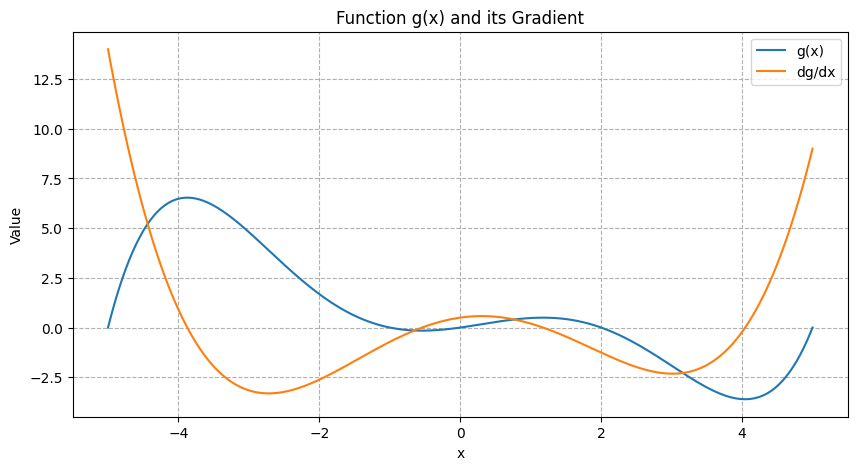

In [4]:
# Detach for plotting
x_np = x_vals.detach().numpy()
g_np = g_vals.detach().numpy()
grad_np = grad_g.detach().numpy()

# Plot function and gradient
plt.figure(figsize=(10,5))
plt.plot(x_np, g_np, label='g(x)')
plt.plot(x_np, grad_np, label='dg/dx')
plt.xlabel('x')
plt.ylabel('Value')
plt.title('Function g(x) and its Gradient')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

## Exercise 3.2 - Optimization using SGD, AdaGrad, and Adam

In [5]:
def optimize(function, optimizer_name, init_value, lr=0.1, steps=20):

    # Parameter to optimize
    x = torch.tensor([init_value], requires_grad=True)

    # Select optimizer
    if optimizer_name == "SGD":
        optimizer = torch.optim.SGD([x], lr=lr)

    elif optimizer_name == "AdaGrad":
        optimizer = torch.optim.Adagrad([x], lr=lr)

    elif optimizer_name == "Adam":
        optimizer = torch.optim.Adam([x], lr=lr)

    else:
        raise ValueError("Unknown optimizer")

    print(f"Optimizer: {optimizer_name}")
    print(f"Initial x = {x.item():.4f}")

    trajectory = []

    for step in range(steps):
        optimizer.zero_grad()
        loss = function(x)
        loss.backward()
        optimizer.step()
        trajectory.append(x.item())

        print(
            f"Step {step+1:2d}: "
            f"x = {x.item():.6f}, "
            f"y = {loss.item():.6f}"
        )

    return trajectory

In [6]:
# Optimize first polynomial f(x)
# Initial value = -4

traj_f_sgd = optimize(f, "SGD", init_value=-4.0, lr=0.1)
traj_f_adagrad = optimize(f, "AdaGrad", init_value=-4.0, lr=1.0)
traj_f_adam = optimize(f, "Adam", init_value=-4.0, lr=1.0)

Optimizer: SGD
Initial x = -4.0000
Step  1: x = -2.300000, y = 37.000000
Step  2: x = -1.280000, y = 13.880000
Step  3: x = -0.668000, y = 5.556800
Step  4: x = -0.300800, y = 2.560448
Step  5: x = -0.080480, y = 1.481761
Step  6: x = 0.051712, y = 1.093434
Step  7: x = 0.131027, y = 0.953636
Step  8: x = 0.178616, y = 0.903309
Step  9: x = 0.207170, y = 0.885191
Step 10: x = 0.224302, y = 0.878669
Step 11: x = 0.234581, y = 0.876321
Step 12: x = 0.240749, y = 0.875475
Step 13: x = 0.244449, y = 0.875171
Step 14: x = 0.246670, y = 0.875062
Step 15: x = 0.248002, y = 0.875022
Step 16: x = 0.248801, y = 0.875008
Step 17: x = 0.249281, y = 0.875003
Step 18: x = 0.249568, y = 0.875001
Step 19: x = 0.249741, y = 0.875000
Step 20: x = 0.249845, y = 0.875000
Optimizer: AdaGrad
Initial x = -4.0000
Step  1: x = -3.000000, y = 37.000000
Step  2: x = -2.392550, y = 22.000000
Step  3: x = -1.949708, y = 14.841141
Step  4: x = -1.603830, y = 10.552428
Step  5: x = -1.323984, y = 7.748370
Step  6: x

In [7]:
# Optimize second polynomial g(x)
# Initial value = -3

traj_g_sgd = optimize(g, "SGD", init_value=-3.0, lr=1.0)
traj_g_adagrad = optimize(g, "AdaGrad", init_value=-3.0, lr=1.0)
traj_g_adam = optimize(g, "Adam", init_value=-3.0, lr=1.0)

Optimizer: SGD
Initial x = -3.0000
Step  1: x = 0.160000, y = 4.800000
Step  2: x = -0.399133, y = 0.085288
Step  3: x = -0.574340, y = -0.142927
Step  4: x = -0.532997, y = -0.155263
Step  5: x = -0.546481, y = -0.155832
Step  6: x = -0.542328, y = -0.155895
Step  7: x = -0.543633, y = -0.155901
Step  8: x = -0.543225, y = -0.155901
Step  9: x = -0.543353, y = -0.155901
Step 10: x = -0.543313, y = -0.155901
Step 11: x = -0.543325, y = -0.155901
Step 12: x = -0.543322, y = -0.155901
Step 13: x = -0.543323, y = -0.155901
Step 14: x = -0.543322, y = -0.155901
Step 15: x = -0.543322, y = -0.155901
Step 16: x = -0.543323, y = -0.155901
Step 17: x = -0.543322, y = -0.155901
Step 18: x = -0.543323, y = -0.155901
Step 19: x = -0.543322, y = -0.155901
Step 20: x = -0.543323, y = -0.155901
Optimizer: AdaGrad
Initial x = -3.0000
Step  1: x = -2.000000, y = 4.800000
Step  2: x = -1.361735, y = 1.680000
Step  3: x = -1.036884, y = 0.383280
Step  4: x = -0.858488, y = 0.027787
Step  5: x = -0.75170

## Exercise 3.3 - Compare learning rates

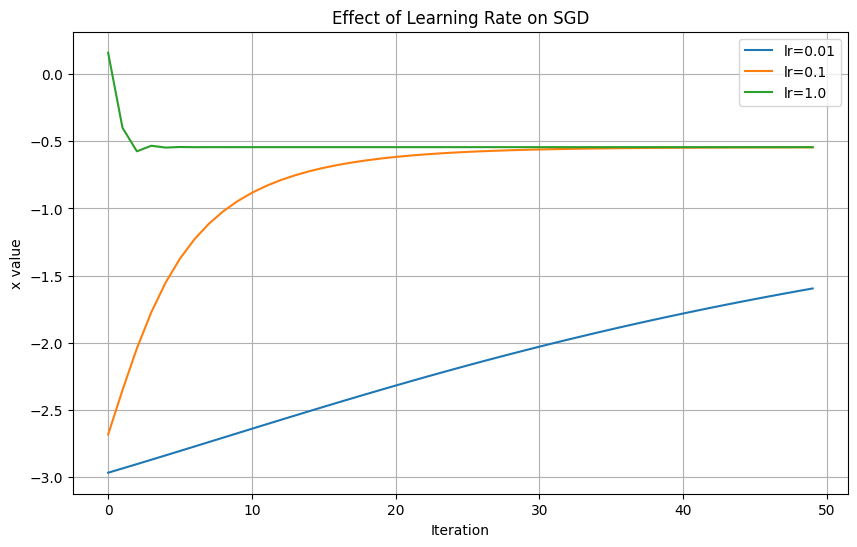

In [8]:
learning_rates = [0.01, 0.1, 1.0]

plt.figure(figsize=(10,6))

for lr in learning_rates:
    x = torch.tensor([-3.0], requires_grad=True)
    optimizer = torch.optim.SGD([x], lr=lr)
    trajectory = []

    for _ in range(50):
        optimizer.zero_grad()
        loss = g(x)
        loss.backward()
        optimizer.step()
        trajectory.append(x.item())

    plt.plot(trajectory, label=f"lr={lr}")

plt.xlabel("Iteration")
plt.ylabel("x value")
plt.title("Effect of Learning Rate on SGD")
plt.legend()
plt.grid(True)
plt.show()